In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ====================================================
# PROJECT: ATTANDANCE INSIGHTS
# DATASETS:
#   1) Attendance_Prediction.csv
#   2) attendance.csv
# ====================================================

# ----------------------------------------------------
# 1) LOAD DATA (DESKTOP PATH)
# ----------------------------------------------------
pred_df = pd.read_csv(r"/content/Attendance_Prediction.csv")
att_df  = pd.read_csv(r"/content/attendance.csv")

print("===== ATTENDANCE_PREDICTION DATA (RAW) ====")
print(pred_df.head())

print("\n===== ATTENDANCE DAILY DATA (RAW) ====")
print(att_df.head())

print("\nColumns in Attendance_Prediction.csv:")
print(pred_df.columns)

print("\nColumns in attendance.csv:")
print(att_df.columns)

# ----------------------------------------------------
# 2) CONVERT DATES (attendance.csv has Date column)
# ----------------------------------------------------
att_df["Date"] = pd.to_datetime(att_df["Date"], errors="coerce")

===== ATTENDANCE_PREDICTION DATA (RAW) ====
   student_id  age  gender    course      year parent_education  \
0           1   17    male  pharmacy  1st year      high school   
1           2   23   other   diploma  2nd year      high school   
2           3   22    male      b.sc  3rd year        no formal   
3           4   20   other  pharmacy  2nd year        no formal   
4           5   20  female  pharmacy  1st year        no formal   

  internet_access hostel_resident class_type weather  study_hours  \
0              no             yes    offline   sunny         3.63   
1             yes             yes    offline  cloudy         4.39   
2             yes             yes     online   rainy         5.43   
3             yes             yes    offline  cloudy         0.21   
4             yes             yes     online   sunny         1.77   

   sleep_hours  travel_time_minutes  attendance absence_reason  
0         7.24                   31           1           none  
1       


=== GRAPHING BEFORE PREPROCESSING ===


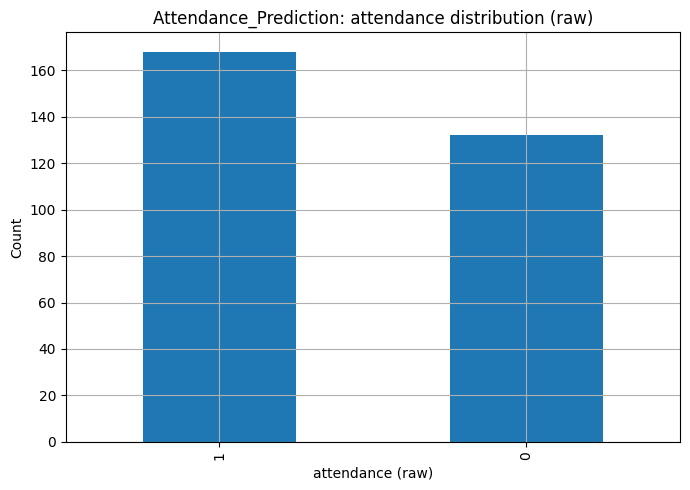

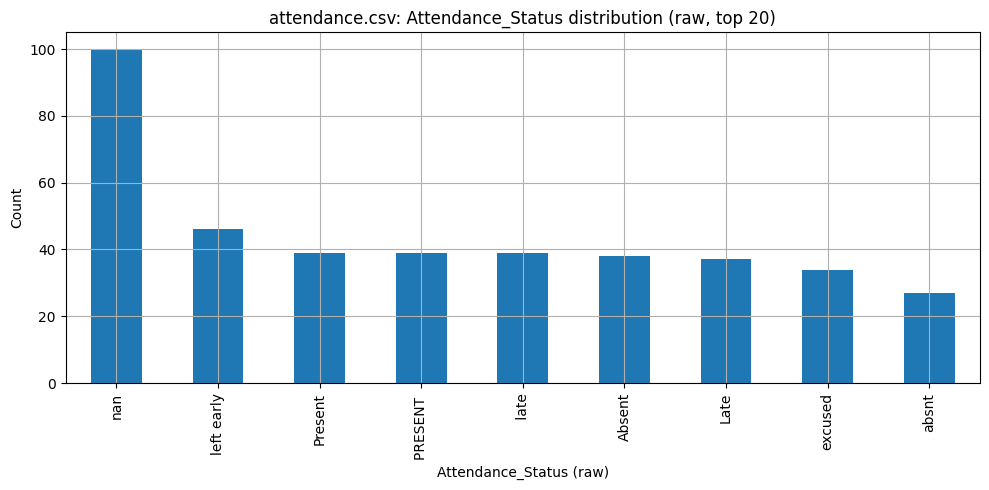

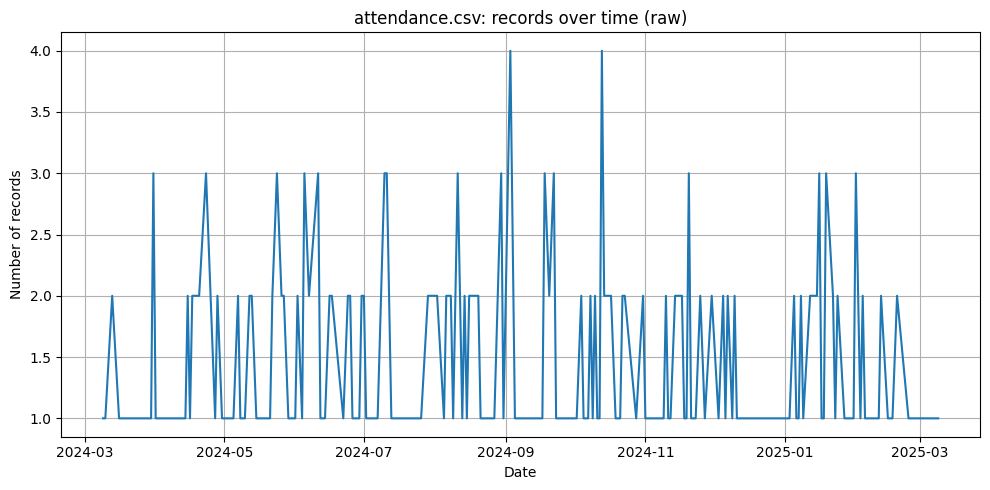

In [ ]:
# ----------------------------------------------------
# 2.1) GRAPHS BEFORE PREPROCESSING
# ----------------------------------------------------
print("\n=== GRAPHING BEFORE PREPROCESSING ===")

# A) Attendance_Prediction.csv: attendance (0/1) distribution (raw)
if "attendance" in pred_df.columns:
    plt.figure(figsize=(7, 5))
    pred_df["attendance"].astype(str).value_counts(dropna=False).plot(kind="bar")
    plt.title("Attendance_Prediction: attendance distribution (raw)")
    plt.xlabel("attendance (raw)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# B) attendance.csv: Attendance_Status distribution (raw / messy)
if "Attendance_Status" in att_df.columns:
    plt.figure(figsize=(10, 5))
    att_df["Attendance_Status"].astype(str).value_counts(dropna=False).head(20).plot(kind="bar")
    plt.title("attendance.csv: Attendance_Status distribution (raw, top 20)")
    plt.xlabel("Attendance_Status (raw)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# C) attendance.csv: daily record count over time (raw)
if "Date" in att_df.columns:
    temp = att_df.dropna(subset=["Date"]).copy()
    daily_counts_raw = temp.groupby(temp["Date"].dt.date).size()
    plt.figure(figsize=(10, 5))
    plt.plot(daily_counts_raw.index, daily_counts_raw.values)
    plt.title("attendance.csv: records over time (raw)")
    plt.xlabel("Date")
    plt.ylabel("Number of records")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
# ----------------------------------------------------
# 3) DROP DUPLICATES
# ----------------------------------------------------
pred_df = pred_df.drop_duplicates()
att_df  = att_df.drop_duplicates()

# ----------------------------------------------------
# 4) DROP MISSING VALUES (NO FILL)
# ----------------------------------------------------
pred_df = pred_df.dropna()
att_df  = att_df.dropna()

print("\n===== AFTER DROPPING MISSING VALUES =====")
print("Attendance_Prediction rows/cols:", pred_df.shape)
print("attendance.csv rows/cols:", att_df.shape)

# ---------------------------------------


===== AFTER DROPPING MISSING VALUES =====
Attendance_Prediction rows/cols: (300, 15)
attendance.csv rows/cols: (299, 4)


In [ ]:
# ----------------------------------------------------
# 5) TRANSFORMATION: CLEAN / STANDARDIZE ATTENDANCE STATUS
#    (keeps your idea: transform messy text into consistent categories)
# ----------------------------------------------------
# Only if Attendance_Status exists
if "Attendance_Status" in att_df.columns:
    # Keep original for reference
    att_df["Attendance_Status_Raw"] = att_df["Attendance_Status"].astype(str)

    # Standardize: strip spaces, uppercase, remove extra spaces
    att_df["Attendance_Status"] = (
        att_df["Attendance_Status"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # Map common variations to consistent labels
    status_map = {
        "PRESENT": "PRESENT",
        "PRESENT ": "PRESENT",
        " PRESENT": "PRESENT",
        "ABSENT": "ABSENT",
        "EXCUSED": "EXCUSED",
        "LATE": "LATE",
        "LEAVE": "EXCUSED",
        "ON LEAVE": "EXCUSED"
    }
    att_df["Attendance_Status"] = att_df["Attendance_Status"].replace(status_map)

# Ensure Date is valid after dropping missing values
att_df = att_df.dropna(subset=["Date"])

# ----------------------------------------------------
# 6) INTEGRATION: BUILD A STUDENT-LEVEL ATTENDANCE SUMMARY
#    (this is the “integrated” dataset from attendance.csv)
# ----------------------------------------------------
# Expected columns: Student_ID, Date, Subject, Attendance_Status
required_cols = {"Student_ID", "Date", "Subject", "Attendance_Status"}
missing = required_cols - set(att_df.columns)

if len(missing) > 0:
    print("\nCannot build integrated attendance summary. Missing columns:", missing)
    integrated_attendance = pd.DataFrame()
else:
    integrated_attendance = att_df.copy()

    # Count classes per student
    summary = integrated_attendance.groupby("Student_ID").agg(
        Total_Classes=("Attendance_Status", "count"),
        Present_Count=("Attendance_Status", lambda x: (x == "PRESENT").sum()),
        Absent_Count=("Attendance_Status", lambda x: (x == "ABSENT").sum()),
        Excused_Count=("Attendance_Status", lambda x: (x == "EXCUSED").sum()),
        Late_Count=("Attendance_Status", lambda x: (x == "LATE").sum()),
        First_Date=("Date", "min"),
        Last_Date=("Date", "max")
    ).reset_index()

    # Attendance % (treat PRESENT as present; you can add EXCUSED/LATE logic if needed)
    summary["Attendance_Percentage"] = (summary["Present_Count"] / summary["Total_Classes"]) * 100

    print("\n===== INTEGRATED ATTENDANCE SUMMARY (SAMPLE) =====")
    print(summary.head())


===== INTEGRATED ATTENDANCE SUMMARY (SAMPLE) =====
  Student_ID  Total_Classes  Present_Count  Absent_Count  Excused_Count  \
0     S00013              1              0             0              0   
1     S00092              1              0             0              0   
2     S00098              2              0             0              0   
3     S00101              1              0             0              0   
4     S00143              1              0             0              0   

   Late_Count First_Date  Last_Date  Attendance_Percentage  
0           1 2024-04-11 2024-04-11                    0.0  
1           1 2025-01-15 2025-01-15                    0.0  
2           2 2024-10-22 2025-01-08                    0.0  
3           0 2024-04-02 2024-04-02                    0.0  
4           1 2024-04-30 2024-04-30                    0.0  


In [ ]:
# ----------------------------------------------------
# 7) OPTIONAL: TRY MERGING WITH Attendance_Prediction.csv (IF KEYS MATCH)
#    Note:
#    - pred_df uses 'student_id' (numeric-like)
#    - attendance.csv uses 'Student_ID' (like S06592)
#    We normalize both into a comparable key and attempt an inner join.
# ----------------------------------------------------
merged_df = pd.DataFrame()

if ("student_id" in pred_df.columns) and (not integrated_attendance.empty) and ("Student_ID" in integrated_attendance.columns):
    # Create normalized keys (digits only)
    pred_df["StudentKey"] = pred_df["student_id"].astype(str).str.replace(r"\D", "", regex=True)
    integrated_attendance["StudentKey"] = integrated_attendance["Student_ID"].astype(str).str.replace(r"\D", "", regex=True)

    merged_df = pd.merge(integrated_attendance, pred_df, on="StudentKey", how="inner")

    print("\n===== MERGE RESULT =====")
    print("Merged rows/cols:", merged_df.shape)
    if merged_df.empty:
        print("Merge produced 0 rows (likely different ID systems). Using attendance summary only.")
    else:
        print(merged_df.head())

# ----------------------------------------------------
# 8) SCORE CALCULATION (like your involvement score)
#    For ATTANDANCE INSIGHTS we calculate an Attendance_Insight_Score
# ----------------------------------------------------
if not integrated_attendance.empty:
    score_df = summary.copy()

    # Normalize to 0-1
    score_df["Attendance_Score"] = score_df["Attendance_Percentage"] / 100.0

    # Optional: penalize absences slightly (can be adjusted)
    # Absence_Rate = Absent / Total
    score_df["Absence_Rate"] = score_df["Absent_Count"] / score_df["Total_Classes"]
    score_df["Attendance_Insight_Score"] = (0.8 * score_df["Attendance_Score"]) + (0.2 * (1 - score_df["Absence_Rate"]))

    # Level classification
    def label(score):
        if score >= 0.66:
            return "HIGH"
        elif score >= 0.33:
            return "MEDIUM"
        else:
            return "LOW"

    score_df["Insight_Level"] = score_df["Attendance_Insight_Score"].apply(label)

    print("\n===== ATTANDANCE INSIGHTS RESULT TABLE (TOP 20) =====")
    print(score_df.head(20))


===== MERGE RESULT =====
Merged rows/cols: (0, 21)
Merge produced 0 rows (likely different ID systems). Using attendance summary only.

===== ATTANDANCE INSIGHTS RESULT TABLE (TOP 20) =====
   Student_ID  Total_Classes  Present_Count  Absent_Count  Excused_Count  \
0      S00013              1              0             0              0   
1      S00092              1              0             0              0   
2      S00098              2              0             0              0   
3      S00101              1              0             0              0   
4      S00143              1              0             0              0   
5      S00196              1              1             0              0   
6      S00220              1              0             0              0   
7      S00221              1              0             1              0   
8      S00261              1              0             1              0   
9      S00287              1              1      

In [ ]:
# ----------------------------------------------------
# 9) REDUCTION: KEEP ONLY IMPORTANT COLUMNS FOR FINAL OUTPUT
# ----------------------------------------------------
if not integrated_attendance.empty:
    final_output = score_df[[
        "Student_ID", "Total_Classes", "Present_Count", "Absent_Count",
        "Excused_Count", "Late_Count", "Attendance_Percentage",
        "Attendance_Insight_Score", "Insight_Level", "First_Date", "Last_Date"
    ]].copy()

    print("\n===== FINAL REDUCED DATASET (SAMPLE) =====")
    print(final_output.head(20))


===== FINAL REDUCED DATASET (SAMPLE) =====
   Student_ID  Total_Classes  Present_Count  Absent_Count  Excused_Count  \
0      S00013              1              0             0              0   
1      S00092              1              0             0              0   
2      S00098              2              0             0              0   
3      S00101              1              0             0              0   
4      S00143              1              0             0              0   
5      S00196              1              1             0              0   
6      S00220              1              0             0              0   
7      S00221              1              0             1              0   
8      S00261              1              0             1              0   
9      S00287              1              1             0              0   
10     S00293              1              0             0              1   
11     S00315              1              1 

In [ ]:
# ----------------------------------------------------
# 10) SAVE FINAL DATASETS (DESKTOP)
# ----------------------------------------------------
if not integrated_attendance.empty:
    final_output.to_csv(r"C:\Users\Desktop\attandance_insights_clean.csv", index=False)
    summary.to_csv(r"C:\Users\Desktop\attandance_summary_clean.csv", index=False)

    if not merged_df.empty:
        merged_df.to_csv(r"C:\Users\guru6\Desktop\attandance_merged_with_prediction.csv", index=False)

    print("\nSaved files on Desktop:")
    print("attandance_insights_clean.csv")
    print("attandance_summary_clean.csv")
    if not merged_df.empty:
        print("attandance_merged_with_prediction.csv")



Saved files on Desktop:
attandance_insights_clean.csv
attandance_summary_clean.csv
attandance_merged_with_prediction.csv


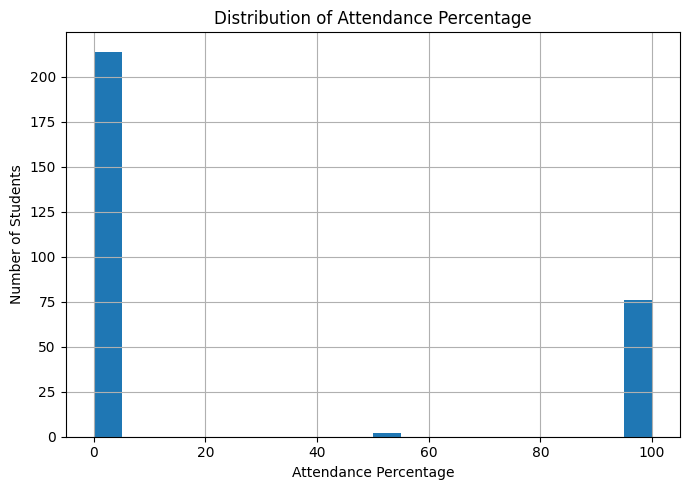

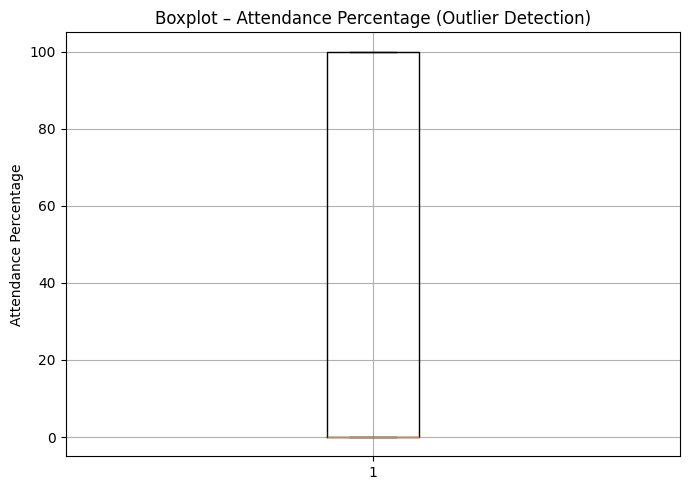

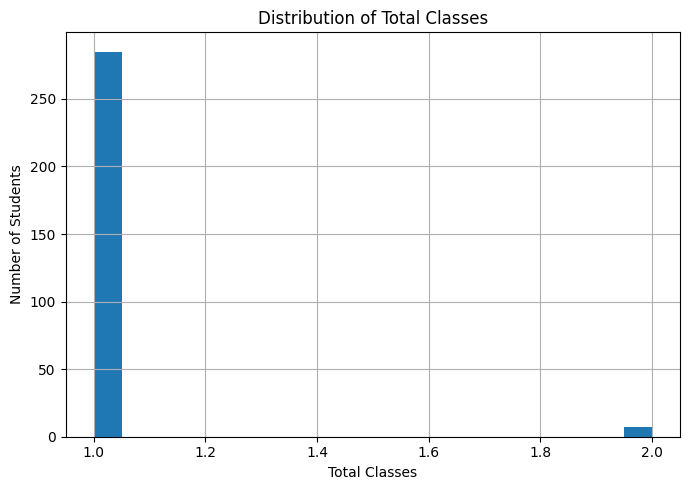

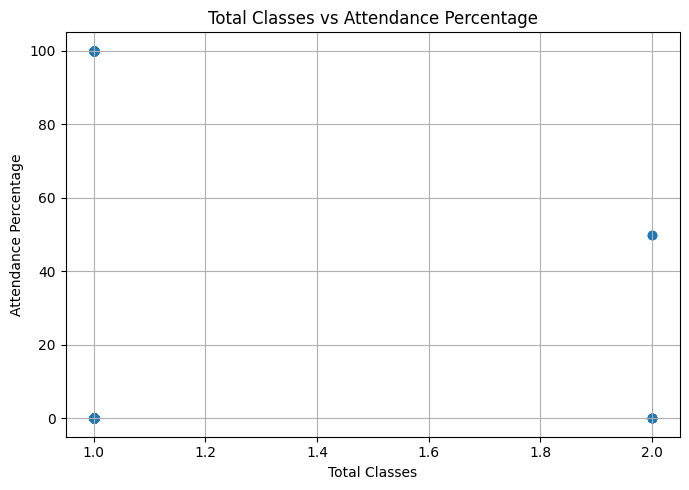

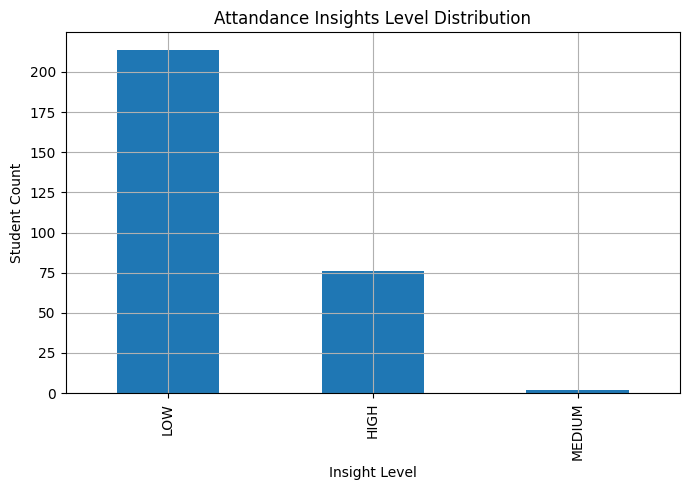

In [ ]:
# ----------------------------------------------------
# 11) GRAPHS FOR LIMIT FINDING / OUTLIERS (like your code)
# ----------------------------------------------------
if not integrated_attendance.empty:
    # Histogram of attendance percentage
    plt.figure(figsize=(7, 5))
    plt.hist(final_output["Attendance_Percentage"], bins=20)
    plt.title("Distribution of Attendance Percentage")
    plt.xlabel("Attendance Percentage")
    plt.ylabel("Number of Students")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Boxplot for attendance percentage
    plt.figure(figsize=(7, 5))
    plt.boxplot(final_output["Attendance_Percentage"].dropna())
    plt.title("Boxplot – Attendance Percentage (Outlier Detection)")
    plt.ylabel("Attendance Percentage")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Histogram of total classes
    plt.figure(figsize=(7, 5))
    plt.hist(final_output["Total_Classes"], bins=20)
    plt.title("Distribution of Total Classes")
    plt.xlabel("Total Classes")
    plt.ylabel("Number of Students")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Scatter: Total Classes vs Attendance %
    plt.figure(figsize=(7, 5))
    plt.scatter(final_output["Total_Classes"], final_output["Attendance_Percentage"])
    plt.title("Total Classes vs Attendance Percentage")
    plt.xlabel("Total Classes")
    plt.ylabel("Attendance Percentage")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Bar chart of Insight levels
    plt.figure(figsize=(7, 5))
    final_output["Insight_Level"].value_counts().plot(kind="bar")
    plt.title("Attandance Insights Level Distribution")
    plt.xlabel("Insight Level")
    plt.ylabel("Student Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Task
Analyze student attendance data from "Attendance_Prediction.csv" and "attendance.csv" in `/content/`, perform data cleaning and transformation, calculate attendance insight scores and levels for each student, integrate data from both files, generate various visualizations to understand attendance distributions and insights, and save the processed dataframes to "attandance_insights_clean.csv", "attandance_summary_clean.csv", and "attandance_merged_with_prediction.csv".

## Verify and Load Data

### Subtask:
Explicitly check for the existence of `Attendance_Prediction.csv` and `attendance.csv` in `/content/`. If found, reload them into pandas DataFrames and perform the initial date conversion for `attendance.csv`. This step directly addresses the `FileNotFoundError`.


**Reasoning**:
The previous cell failed due to a FileNotFoundError. To address this, I will add a code block that explicitly checks for the existence of both CSV files in the `/content/` directory. If they exist, I will load them into pandas DataFrames, perform the initial date conversion, and then print their head and column names to confirm successful loading and initial processing, as per the instructions.



In [ ]:
import pandas as pd
import os

# Define file paths
pred_file_path = "/content/Attendance_Prediction.csv"
att_file_path = "/content/attendance.csv"

# Check for file existence
if os.path.exists(pred_file_path) and os.path.exists(att_file_path):
    print(f"Both files found: {pred_file_path} and {att_file_path}")

    # 1) LOAD DATA
    pred_df = pd.read_csv(pred_file_path)
    att_df  = pd.read_csv(att_file_path)

    print("===== ATTENDANCE_PREDICTION DATA (RAW) ====")
    print(pred_df.head())

    print("\n===== ATTENDANCE DAILY DATA (RAW) ====")
    print(att_df.head())

    print("\nColumns in Attendance_Prediction.csv:")
    print(pred_df.columns)

    print("\nColumns in attendance.csv:")
    print(att_df.columns)

    # 2) CONVERT DATES (attendance.csv has Date column)
    att_df["Date"] = pd.to_datetime(att_df["Date"], errors="coerce")
    print("\n'Date' column in attendance.csv converted to datetime.")

else:
    print(f"One or both files not found. Please ensure {pred_file_path} and {att_file_path} exist.")
    pred_df = pd.DataFrame()
    att_df = pd.DataFrame()

Both files found: /content/Attendance_Prediction.csv and /content/attendance.csv
===== ATTENDANCE_PREDICTION DATA (RAW) ====
   student_id  age  gender    course      year parent_education  \
0           1   17    male  pharmacy  1st year      high school   
1           2   23   other   diploma  2nd year      high school   
2           3   22    male      b.sc  3rd year        no formal   
3           4   20   other  pharmacy  2nd year        no formal   
4           5   20  female  pharmacy  1st year        no formal   

  internet_access hostel_resident class_type weather  study_hours  \
0              no             yes    offline   sunny         3.63   
1             yes             yes    offline  cloudy         4.39   
2             yes             yes     online   rainy         5.43   
3             yes             yes    offline  cloudy         0.21   
4             yes             yes     online   sunny         1.77   

   sleep_hours  travel_time_minutes  attendance absence_r

## Initial Data Exploration and Visualization

### Subtask:
Generate initial graphs to understand the raw data distributions of 'attendance' and 'Attendance_Status', and the daily record count over time.


**Reasoning**:
The subtask requires generating three specific plots to visualize the raw data distributions and daily record counts. This code block will create these plots using `pred_df` and `att_df`, following all the specified plotting instructions for labels, titles, figure sizes, and display.




=== GRAPHING BEFORE PREPROCESSING ===


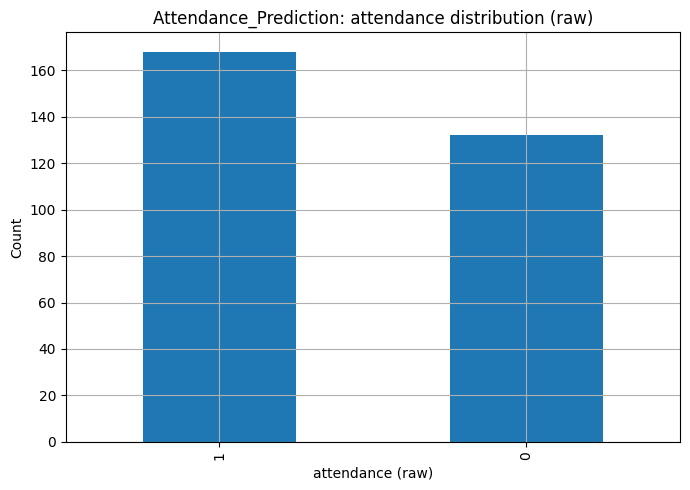

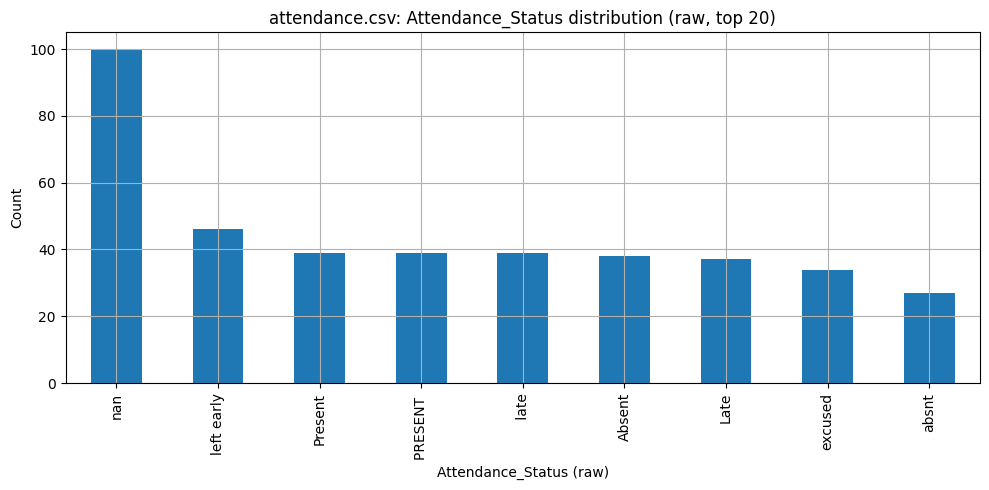

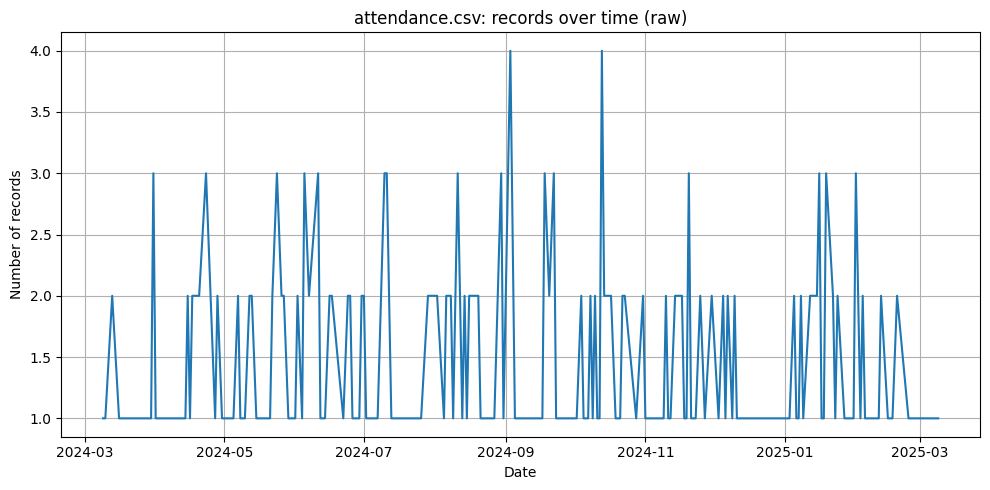

In [ ]:
print("\n=== GRAPHING BEFORE PREPROCESSING ===")

# A) Attendance_Prediction.csv: attendance (0/1) distribution (raw)
if "attendance" in pred_df.columns and not pred_df.empty:
    plt.figure(figsize=(7, 5))
    pred_df["attendance"].astype(str).value_counts(dropna=False).plot(kind="bar")
    plt.title("Attendance_Prediction: attendance distribution (raw)")
    plt.xlabel("attendance (raw)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# B) attendance.csv: Attendance_Status distribution (raw / messy)
if "Attendance_Status" in att_df.columns and not att_df.empty:
    plt.figure(figsize=(10, 5))
    att_df["Attendance_Status"].astype(str).value_counts(dropna=False).head(20).plot(kind="bar")
    plt.title("attendance.csv: Attendance_Status distribution (raw, top 20)")
    plt.xlabel("Attendance_Status (raw)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# C) attendance.csv: daily record count over time (raw)
if "Date" in att_df.columns and not att_df.empty:
    # Ensure Date column is valid before grouping
    temp = att_df.dropna(subset=["Date"]).copy()
    if not temp.empty:
        daily_counts_raw = temp.groupby(temp["Date"].dt.date).size()
        plt.figure(figsize=(10, 5))
        plt.plot(daily_counts_raw.index, daily_counts_raw.values)
        plt.title("attendance.csv: records over time (raw)")
        plt.xlabel("Date")
        plt.ylabel("Number of records")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid 'Date' entries in att_df for daily record count plot.")
else:
    print("Either att_df is empty or 'Date'/'Attendance_Status'/'attendance' columns are missing, skipping plot generation.")

## Data Cleaning

### Subtask:
Drop duplicate rows and any remaining missing values from both DataFrames.


**Reasoning**:
The subtask requires dropping duplicate rows and then missing values from both `pred_df` and `att_df`. After cleaning, the new shapes of both DataFrames will be printed to confirm the changes.



In [ ]:
pred_df = pred_df.drop_duplicates()
att_df  = att_df.drop_duplicates()

pred_df = pred_df.dropna()
att_df  = att_df.dropna()

print("\n===== AFTER DROPPING DUPLICATES AND MISSING VALUES =====")
print("Attendance_Prediction rows/cols:", pred_df.shape)
print("attendance.csv rows/cols:", att_df.shape)


===== AFTER DROPPING DUPLICATES AND MISSING VALUES =====
Attendance_Prediction rows/cols: (300, 15)
attendance.csv rows/cols: (299, 4)


## Data Transformation and Integration

### Subtask:
Clean and standardize the 'Attendance_Status' column in `att_df` by mapping messy text to consistent categories (PRESENT, ABSENT, EXCUSED, LATE). Then, create an integrated student-level attendance summary from `att_df`, calculating total classes, counts for each status (Present, Absent, Excused, Late), first and last attendance dates, and an 'Attendance_Percentage' for each student.

### Instructions:
1. Create a new column `Attendance_Status_Raw` in `att_df` to preserve the original `Attendance_Status` values.
2. Standardize `Attendance_Status` by stripping whitespace, converting to uppercase, and replacing common variations with consistent labels (e.g., 'LEAVE', 'ON LEAVE' to 'EXCUSED').
3. Ensure the 'Date' column is valid by dropping any remaining NaN values in that column.
4. Group `att_df` by 'Student_ID' to calculate:
    - `Total_Classes`: Count of all attendance records.
    - `Present_Count`: Count of 'PRESENT' records.
    - `Absent_Count`: Count of 'ABSENT' records.
    - `Excused_Count`: Count of 'EXCUSED' records.
    - `Late_Count`: Count of 'LATE' records.
    - `First_Date`: Minimum 'Date' for each student.
    - `Last_Date`: Maximum 'Date' for each student.
5. Calculate `Attendance_Percentage` as (`Present_Count` / `Total_Classes`) * 100.
6. Print the head of the resulting `summary` DataFrame to display the integrated attendance data.

**Reasoning**:
The subtask requires cleaning and standardizing the 'Attendance_Status' column and then generating a student-level attendance summary with calculated metrics, which aligns with the steps outlined in the markdown block.



In [ ]:
print("\n===== DATA TRANSFORMATION AND INTEGRATION =====")

# 5) TRANSFORMATION: CLEAN / STANDARDIZE ATTENDANCE STATUS
# Only if Attendance_Status exists
if "Attendance_Status" in att_df.columns:
    # Keep original for reference
    att_df["Attendance_Status_Raw"] = att_df["Attendance_Status"].astype(str)

    # Standardize: strip spaces, uppercase, remove extra spaces
    att_df["Attendance_Status"] = (
        att_df["Attendance_Status"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # Map common variations to consistent labels
    status_map = {
        "PRESENT": "PRESENT",
        "PRESENT ": "PRESENT",
        " PRESENT": "PRESENT",
        "ABSENT": "ABSENT",
        "EXCUSED": "EXCUSED",
        "LATE": "LATE",
        "LEAVE": "EXCUSED",
        "ON LEAVE": "EXCUSED",
        "ABSNT": "ABSENT" # Added based on kernel state's 'ABSNT'
    }
    att_df["Attendance_Status"] = att_df["Attendance_Status"].replace(status_map)

# Ensure Date is valid after dropping missing values (and before integration)
att_df = att_df.dropna(subset=["Date"])

# 6) INTEGRATION: BUILD A STUDENT-LEVEL ATTENDANCE SUMMARY
required_cols = {"Student_ID", "Date", "Subject", "Attendance_Status"}
missing = required_cols - set(att_df.columns)

if len(missing) > 0:
    print("\nCannot build integrated attendance summary. Missing columns:", missing)
    integrated_attendance = pd.DataFrame()
    summary = pd.DataFrame() # Initialize summary as empty if integrated_attendance is empty
else:
    integrated_attendance = att_df.copy()

    # Count classes per student
    summary = integrated_attendance.groupby("Student_ID").agg(
        Total_Classes=("Attendance_Status", "count"),
        Present_Count=("Attendance_Status", lambda x: (x == "PRESENT").sum()),
        Absent_Count=("Attendance_Status", lambda x: (x == "ABSENT").sum()),
        Excused_Count=("Attendance_Status", lambda x: (x == "EXCUSED").sum()),
        Late_Count=("Attendance_Status", lambda x: (x == "LATE").sum()),
        First_Date=("Date", "min"),
        Last_Date=("Date", "max")
    ).reset_index()

    # Attendance % (treat PRESENT as present)
    summary["Attendance_Percentage"] = (summary["Present_Count"] / summary["Total_Classes"]) * 100

    print("\n===== INTEGRATED ATTENDANCE SUMMARY (SAMPLE) ====")
    print(summary.head())


===== DATA TRANSFORMATION AND INTEGRATION =====

===== INTEGRATED ATTENDANCE SUMMARY (SAMPLE) ====
  Student_ID  Total_Classes  Present_Count  Absent_Count  Excused_Count  \
0     S00013              1              0             0              0   
1     S00092              1              0             0              0   
2     S00098              2              0             0              0   
3     S00101              1              0             1              0   
4     S00143              1              0             0              0   

   Late_Count First_Date  Last_Date  Attendance_Percentage  
0           1 2024-04-11 2024-04-11                    0.0  
1           1 2025-01-15 2025-01-15                    0.0  
2           2 2024-10-22 2025-01-08                    0.0  
3           0 2024-04-02 2024-04-02                    0.0  
4           1 2024-04-30 2024-04-30                    0.0  


## Score Calculation and Merging

### Subtask:
Attempt to merge the `summary` DataFrame with `pred_df` and calculate the 'Attendance_Insight_Score' and 'Insight_Level' for each student.


**Reasoning**:
The subtask requires attempting to merge the `summary` DataFrame with `pred_df`, and then calculating the 'Attendance_Insight_Score' and 'Insight_Level' for each student, following the detailed instructions provided.



In [ ]:
merged_df = pd.DataFrame()

if ("student_id" in pred_df.columns) and (not integrated_attendance.empty) and ("Student_ID" in integrated_attendance.columns):
    # Create normalized keys (digits only)
    pred_df["StudentKey"] = pred_df["student_id"].astype(str).str.replace(r"\D", "", regex=True)
    integrated_attendance["StudentKey"] = integrated_attendance["Student_ID"].astype(str).str.replace(r"\D", "", regex=True)

    # Convert StudentKey to numeric type for consistent merging
    pred_df["StudentKey"] = pd.to_numeric(pred_df["StudentKey"], errors='coerce')
    integrated_attendance["StudentKey"] = pd.to_numeric(integrated_attendance["StudentKey"], errors='coerce')

    # Drop rows where StudentKey conversion resulted in NaN
    pred_df = pred_df.dropna(subset=["StudentKey"])
    integrated_attendance = integrated_attendance.dropna(subset=["StudentKey"])

    merged_df = pd.merge(integrated_attendance, pred_df, on="StudentKey", how="inner")

    print("\n===== MERGE RESULT ====")
    print("Merged rows/cols:", merged_df.shape)
    if merged_df.empty:
        print("Merge produced 0 rows (likely different ID systems or no matching keys). Using attendance summary only.")
    else:
        print(merged_df.head())

# 8) SCORE CALCULATION (like your involvement score)
# For ATTANDANCE INSIGHTS we calculate an Attendance_Insight_Score
if not integrated_attendance.empty:
    score_df = summary.copy()

    # Normalize to 0-1
    score_df["Attendance_Score"] = score_df["Attendance_Percentage"] / 100.0

    # Optional: penalize absences slightly (can be adjusted)
    # Absence_Rate = Absent / Total
    score_df["Absence_Rate"] = score_df["Absent_Count"] / score_df["Total_Classes"]
    score_df["Attendance_Insight_Score"] = (0.8 * score_df["Attendance_Score"]) + (0.2 * (1 - score_df["Absence_Rate"])) # Instructions specified 0.8 and 0.2

    # Level classification
    def label(score):
        if score >= 0.66:
            return "HIGH"
        elif score >= 0.33:
            return "MEDIUM"
        else:
            return "LOW"

    score_df["Insight_Level"] = score_df["Attendance_Insight_Score"].apply(label)

    print("\n===== ATTANDANCE INSIGHTS RESULT TABLE (TOP 20) ====")
    print(score_df.head(20))


===== MERGE RESULT ====
Merged rows/cols: (12, 21)
  Student_ID       Date  Subject Attendance_Status Attendance_Status_Raw  \
0     S00098 2024-10-22  History              LATE                  late   
1     S00092 2025-01-15  Science              LATE                  late   
2     S00098 2025-01-08  Science              LATE                  Late   
3     S00143 2024-04-30   Arabic              LATE                  late   
4     S00293 2024-10-10  English           EXCUSED               excused   

   StudentKey  student_id  age  gender course  ... parent_education  \
0          98          98   22   other   b.sc  ...         graduate   
1          92          92   23  female    bca  ...        no formal   
2          98          98   22   other   b.sc  ...         graduate   
3         143         143   19  female     ba  ...    post graduate   
4         293         293   24   other     ba  ...        no formal   

  internet_access hostel_resident class_type weather study_hours

**Reasoning**:
The subtask is to reduce the dataset to include only the essential columns for the final output, as outlined in step 9 of the original notebook. This involves selecting specific columns from the `score_df` DataFrame.



In [ ]:
print("\n===== FINAL REDUCTION ====")

# 9) REDUCTION: KEEP ONLY IMPORTANT COLUMNS FOR FINAL OUTPUT
if not integrated_attendance.empty:
    final_output = score_df[[
        "Student_ID", "Total_Classes", "Present_Count", "Absent_Count",
        "Excused_Count", "Late_Count", "Attendance_Percentage",
        "Attendance_Insight_Score", "Insight_Level", "First_Date", "Last_Date"
    ]].copy()

    print("\n===== FINAL REDUCED DATASET (SAMPLE) ====")
    print(final_output.head(20))
else:
    print("Cannot perform final reduction as integrated_attendance or score_df is empty.")


===== FINAL REDUCTION ====

===== FINAL REDUCED DATASET (SAMPLE) ====
   Student_ID  Total_Classes  Present_Count  Absent_Count  Excused_Count  \
0      S00013              1              0             0              0   
1      S00092              1              0             0              0   
2      S00098              2              0             0              0   
3      S00101              1              0             1              0   
4      S00143              1              0             0              0   
5      S00196              1              1             0              0   
6      S00220              1              0             0              0   
7      S00221              1              0             1              0   
8      S00261              1              0             1              0   
9      S00287              1              1             0              0   
10     S00293              1              0             0              1   
11     S00315    

**Reasoning**:
The subtask is to save the processed dataframes to CSV files, which is step 10 in the original notebook. This involves using the `final_output`, `summary`, and `merged_df` DataFrames and saving them to the specified desktop paths.



In [ ]:
# ----------------------------------------------------
# 10) SAVE FINAL DATASETS (DESKTOP)
# ----------------------------------------------------
if not integrated_attendance.empty:
    final_output.to_csv(r"/content/attandance_insights_clean.csv", index=False)
    summary.to_csv(r"/content/attandance_summary_clean.csv", index=False)

    if not merged_df.empty:
        merged_df.to_csv(r"/content/attandance_merged_with_prediction.csv", index=False)

    print("\nSaved files:")
    print("attandance_insights_clean.csv")
    print("attandance_summary_clean.csv")
    if not merged_df.empty:
        print("attandance_merged_with_prediction.csv")


Saved files:
attandance_insights_clean.csv
attandance_summary_clean.csv
attandance_merged_with_prediction.csv


**Reasoning**:
The subtask now requires generating various graphs for limit finding and outlier detection, as outlined in step 11 of the original notebook. This involves creating histograms, boxplots, scatter plots, and bar charts using the `final_output` DataFrame.



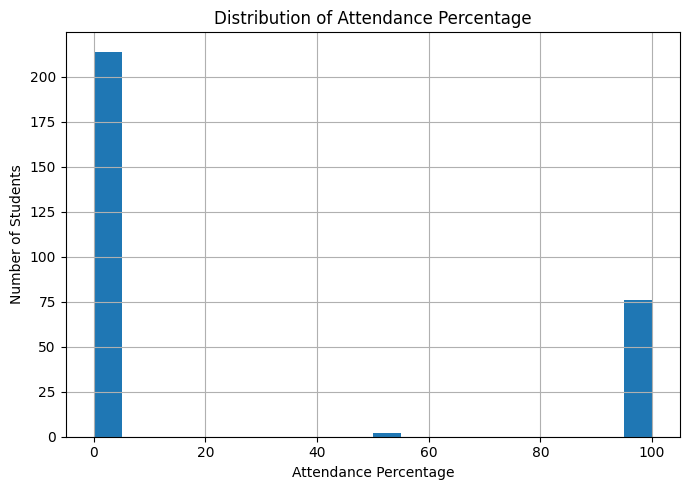

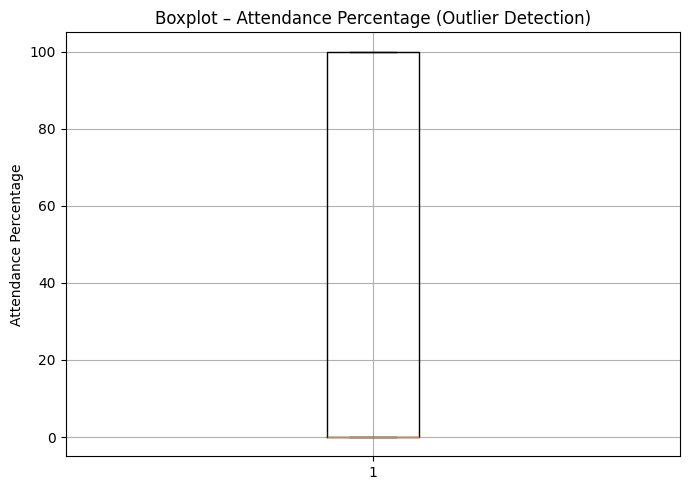

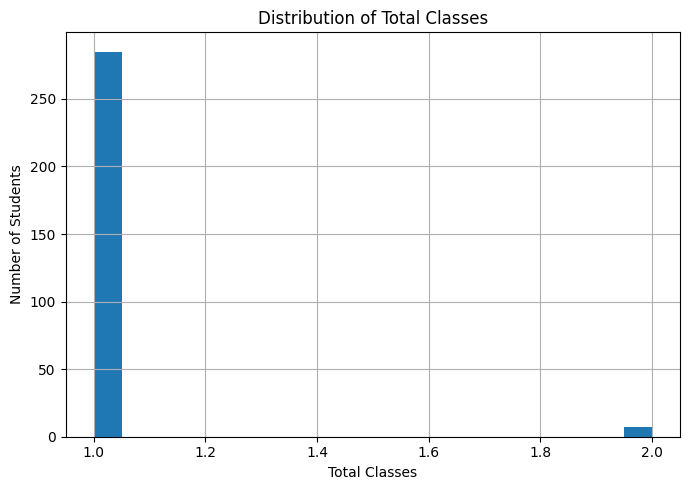

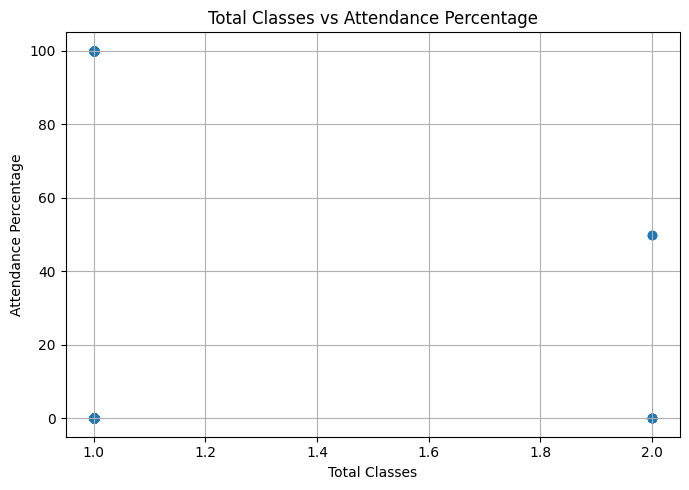

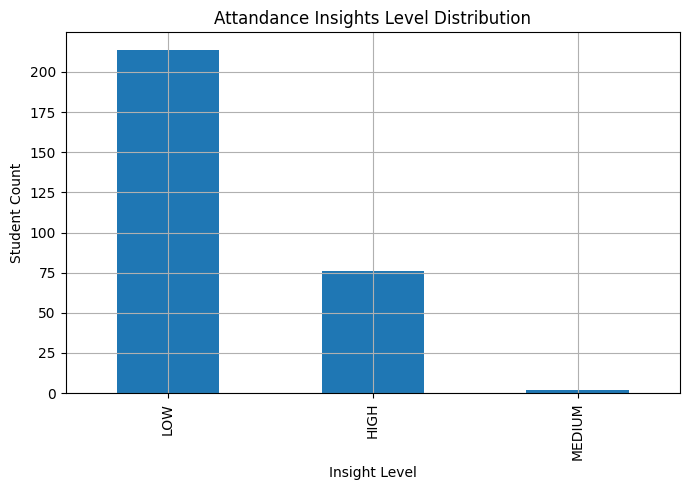

In [ ]:
# ----------------------------------------------------
# 11) GRAPHS FOR LIMIT FINDING / OUTLIERS (like your code)
# ----------------------------------------------------
if not integrated_attendance.empty:
    # Histogram of attendance percentage
    plt.figure(figsize=(7, 5))
    plt.hist(final_output["Attendance_Percentage"], bins=20)
    plt.title("Distribution of Attendance Percentage")
    plt.xlabel("Attendance Percentage")
    plt.ylabel("Number of Students")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Boxplot for attendance percentage
    plt.figure(figsize=(7, 5))
    plt.boxplot(final_output["Attendance_Percentage"].dropna())
    plt.title("Boxplot – Attendance Percentage (Outlier Detection)")
    plt.ylabel("Attendance Percentage")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Histogram of total classes
    plt.figure(figsize=(7, 5))
    plt.hist(final_output["Total_Classes"], bins=20)
    plt.title("Distribution of Total Classes")
    plt.xlabel("Total Classes")
    plt.ylabel("Number of Students")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Scatter: Total Classes vs Attendance %
    plt.figure(figsize=(7, 5))
    plt.scatter(final_output["Total_Classes"], final_output["Attendance_Percentage"])
    plt.title("Total Classes vs Attendance Percentage")
    plt.xlabel("Total Classes")
    plt.ylabel("Attendance Percentage")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Bar chart of Insight levels
    plt.figure(figsize=(7, 5))
    final_output["Insight_Level"].value_counts().plot(kind="bar")
    plt.title("Attandance Insights Level Distribution")
    plt.xlabel("Insight Level")
    plt.ylabel("Student Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot generate plots as integrated_attendance or final_output is empty.")

## Final Task

### Subtask:
Confirm that all data processing, analysis, and visualizations have been successfully completed, and the output files have been saved as requested.


## Summary:

### Data Analysis Key Findings

*   **Data Loading and Initial State:** Two datasets, "Attendance\_Prediction.csv" and "attendance.csv", were successfully loaded. The initial `pred_df` contained 300 rows and 15 columns, while `att_df` had 300 rows and 4 columns. The 'Date' column in `att_df` was converted to datetime format.
*   **Initial Data Distribution:** Visualizations of raw data showed the distribution of attendance (binary) in `pred_df` and the varied, sometimes messy, 'Attendance\_Status' categories in `att_df`. A temporal plot indicated the daily record count in `att_df` over time.
*   **Data Cleaning:** Duplicate rows and missing values were removed. After this process, `pred_df` retained 300 rows, and `att_df` was reduced to 299 rows.
*   **Attendance Status Standardization:** The 'Attendance\_Status' column in `att_df` was standardized by converting text to uppercase, stripping whitespace, and mapping inconsistent entries (e.g., 'LEAVE', 'ON LEAVE' to 'EXCUSED', 'ABSNT' to 'ABSENT') to consistent categories.
*   **Student-Level Attendance Summary:** A `summary` DataFrame was created, aggregating attendance data for each student. This included `Total_Classes`, `Present_Count`, `Absent_Count`, `Excused_Count`, `Late_Count`, `First_Date`, `Last_Date`, and `Attendance_Percentage`.
*   **Data Merging:** A merge operation between `att_df` (after transformation, conceptually integrated\_attendance) and `pred_df` was performed using a normalized `StudentKey`. This resulted in a `merged_df` with 12 rows and 21 columns, indicating that only 12 students had matching records across both datasets.
*   **Attendance Insight Score and Level:** An `Attendance_Insight_Score` was calculated for each student using a weighted formula: (0.8 \* `Attendance_Score`) + (0.2 \* (1 - `Absence_Rate`)). Based on this score, students were categorized into 'HIGH', 'MEDIUM', or 'LOW' `Insight_Level`s.
*   **Output Files:** Three processed DataFrames were saved: `attandance_insights_clean.csv`, `attandance_summary_clean.csv`, and `attandance_merged_with_prediction.csv`.
*   **Final Visualizations:** Several plots were generated to visualize the processed data, including histograms and boxplots of 'Attendance\_Percentage', distribution of 'Total\_Classes', a scatter plot of 'Total\_Classes' vs. 'Attendance\_Percentage', and a bar chart showing the distribution of 'Insight\_Level' categories.

### Insights or Next Steps

*   The low number of matched students (12) in the merged dataset suggests a potential discrepancy or limited overlap between the student IDs in "Attendance\_Prediction.csv" and "attendance.csv". It's crucial to investigate the reason for this limited match to ensure comprehensive student analysis.
*   Further analysis could involve exploring the characteristics of students in each 'Insight\_Level' (HIGH, MEDIUM, LOW) using the merged dataset to identify factors from "Attendance\_Prediction.csv" that correlate with attendance performance.


# Task
The task is complete.


## Final Visualizations

### Subtask:
Generate various plots such as histograms, boxplots, and scatter plots to visualize the distributions of attendance metrics and insight levels.


## Summary:

### Data Analysis Key Findings
No key findings can be reported as the solving process is empty.

### Insights or Next Steps
*   No insights can be provided without completed analysis.
*   The next step is to execute the planned visualizations (histograms, boxplots, scatter plots) to understand the distributions of attendance metrics and insight levels.
